<a href="https://colab.research.google.com/github/abisolami/jobbermann-skill-tracker/blob/main/skill_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Jobbermann Skill Tracker**


**Problem Statement**

 ---




**Aim**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ast
import re
from collections import Counter

In [57]:
url = 'https://raw.githubusercontent.com/abisolami/jobbermann-skill-tracker/refs/heads/main/jobberman_jobs.csv'
df = pd.read_csv(url)

data = df.copy()

In [58]:
data.head()

,job_title,website,company,location,working_hour,salary_range,job_category,date_posted,minimum_qualification,experience_level,experience_length,remuneration,job_summary,responsibilities,requirement
0,Marketing/Sales Representative,https://www.jobberman.com/jobs?page=1,Stevian Foods Ltd,Lagos,Full Time,"NGN 150,000 - 250,000",Sales,Today,OND,Entry level,2 years,NaN,We are seeking experienced and results-driven ...,['Develop and implement effective sales and ma...,"['Minimum of an OND in marketing, business adm..."
1,Senior Mechanical Engineer.,https://www.jobberman.com/jobs?page=1,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Executive level,15 years,NaN,The successful candidate will be responsible f...,"['Design, develop, and maintain mechanical sys...",['Bachelor’s degree in Mechanical Engineering ...
2,Mechanical engineer,https://www.jobberman.com/jobs?page=1,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Senior level,5 years,NaN,The successful candidate will be responsible f...,['Support the design and development of mechan...,"[""A minimum of a bachelor's degree in mechanic..."
3,Architect,https://www.jobberman.com/jobs?page=1,Anonymous Employer,Lagos,Full Time,Confidential,Building & Architecture,Today,Degree,Senior level,5 years,NaN,This role is ideal for recent graduates or ear...,['Assist in developing innovative design solut...,"['A minimum of a degree in architecture.', 'A ..."
4,Administrative Manager,https://www.jobberman.com/jobs?page=1,Dyslexia Nigeria,Lagos,Full Time,"NGN 150,000 - 250,000",Admin & Office,Yesterday,Degree,Senior level,5 years,NaN,We seek to hire a suitable candidate for this ...,"['Develop and implement HR policies, recruitme...","['Coordinate daily administrative operations, ..."


In [59]:
data.shape

(3463, 15)

In [60]:
data.describe()

,job_title,website,company,location,working_hour,salary_range,job_category,date_posted,minimum_qualification,experience_level,experience_length,remuneration,job_summary,responsibilities,requirement
count,3463,3463,3463,3463,3463,3463,3461,3463,3463,3463,3461,16,3463,3456,3454
unique,1741,217,1223,37,4,20,26,11,13,11,17,11,3278,3301,3120
top,Sales Representative,https://www.jobberman.com/jobs?page=1,Kenex Konsults International,Lagos,Full Time,"NGN 70,000 - 150,000",Sales,1 month ago,Degree,Entry level,2 years,Remuneration & Benefits:,We seek to hire a suitable candidate for this ...,['Identify and pursue new sales opportunities ...,"['Minimum BSC', '2 years of previous experienc..."
freq,111,16,138,2098,3263,1521,491,1375,1801,1984,1178,5,30,23,22


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3463 entries, 0 to 3462
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   job_title              3463 non-null   object
 1   website                3463 non-null   object
 2   company                3463 non-null   object
 3   location               3463 non-null   object
 4   working_hour           3463 non-null   object
 5   salary_range           3463 non-null   object
 6   job_category           3461 non-null   object
 7   date_posted            3463 non-null   object
 8   minimum_qualification  3463 non-null   object
 9   experience_level       3463 non-null   object
 10  experience_length      3461 non-null   object
 11  remuneration           16 non-null     object
 12  job_summary            3463 non-null   object
 13  responsibilities       3456 non-null   object
 14  requirement            3454 non-null   object
dtypes: object(15)
memory 

In [62]:
data.isna().sum()

,0
job_title,0
website,0
company,0
location,0
working_hour,0
salary_range,0
job_category,2
date_posted,0
minimum_qualification,0
experience_level,0


## **Data Cleaning**

*The **Remuneration** feature has over 90% null values which is found not useful for this analysis as well as the **Website** attribute*

In [63]:
data.drop(['website', 'remuneration'], axis=1, inplace=True)
data.head(3)

,job_title,company,location,working_hour,salary_range,job_category,date_posted,minimum_qualification,experience_level,experience_length,job_summary,responsibilities,requirement
0,Marketing/Sales Representative,Stevian Foods Ltd,Lagos,Full Time,"NGN 150,000 - 250,000",Sales,Today,OND,Entry level,2 years,We are seeking experienced and results-driven ...,['Develop and implement effective sales and ma...,"['Minimum of an OND in marketing, business adm..."
1,Senior Mechanical Engineer.,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Executive level,15 years,The successful candidate will be responsible f...,"['Design, develop, and maintain mechanical sys...",['Bachelor’s degree in Mechanical Engineering ...
2,Mechanical engineer,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Senior level,5 years,The successful candidate will be responsible f...,['Support the design and development of mechan...,"[""A minimum of a bachelor's degree in mechanic..."


**Target Variable Analysis**

In [64]:
# checking the salary range data
data[['salary_range', 'experience_level']].value_counts()

,,count
salary_range,experience_level,
"NGN 70,000 - 150,000",Entry level,1268
"NGN 150,000 - 250,000",Entry level,507
"NGN 250,000 - 400,000",Mid level,360
"NGN 150,000 - 250,000",Mid level,311
"NGN 400,000 - 600,000",Mid level,135
"NGN 70,000 - 150,000",Mid level,123
"NGN 250,000 - 400,000",Entry level,123
"NGN 70,000 - 150,000",No Experience,78
"NGN 600,000 - 900,000",Senior level,76


In [65]:
# Handling the USD rows by converting to NGN

# cost of 1usd to naira at the moment
USD_NGN = 1361

# function that convert usd rows to naira
def clean_salary(salary_str):
  # to remove the confidential and commission
  if salary_str == 'Confidential' or 'Commission Only' in salary_str:
    return None

  # converting usd to naira
  if 'USD' in salary_str:
    multiplier = USD_NGN
  else: #if its naira
    multiplier = 1

  # now remove the currency text like the comma and the currency type
  salary_str = salary_str.replace('NGN', '').replace('USD', '').replace(',', '').strip()

# getting rid of the above word
  if 'Above' in salary_str:
    value = float(salary_str.replace('Above', '').replace(',', '').strip())
    return value * multiplier

  salary_str = salary_str.split('-')

  lower_bound = float(salary_str[0].strip()) * multiplier
  upper_bound = float(salary_str[1].strip()) * multiplier

  midpoint = (lower_bound + upper_bound) / 2

  return midpoint

data['salary_mid'] = data['salary_range'].apply(clean_salary)

data.head()




,job_title,company,location,working_hour,salary_range,job_category,date_posted,minimum_qualification,experience_level,experience_length,job_summary,responsibilities,requirement,salary_mid
0,Marketing/Sales Representative,Stevian Foods Ltd,Lagos,Full Time,"NGN 150,000 - 250,000",Sales,Today,OND,Entry level,2 years,We are seeking experienced and results-driven ...,['Develop and implement effective sales and ma...,"['Minimum of an OND in marketing, business adm...",200000.0
1,Senior Mechanical Engineer.,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Executive level,15 years,The successful candidate will be responsible f...,"['Design, develop, and maintain mechanical sys...",['Bachelor’s degree in Mechanical Engineering ...,NaN
2,Mechanical engineer,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Senior level,5 years,The successful candidate will be responsible f...,['Support the design and development of mechan...,"[""A minimum of a bachelor's degree in mechanic...",NaN
3,Architect,Anonymous Employer,Lagos,Full Time,Confidential,Building & Architecture,Today,Degree,Senior level,5 years,This role is ideal for recent graduates or ear...,['Assist in developing innovative design solut...,"['A minimum of a degree in architecture.', 'A ...",NaN
4,Administrative Manager,Dyslexia Nigeria,Lagos,Full Time,"NGN 150,000 - 250,000",Admin & Office,Yesterday,Degree,Senior level,5 years,We seek to hire a suitable candidate for this ...,"['Develop and implement HR policies, recruitme...","['Coordinate daily administrative operations, ...",200000.0


In [66]:
print(f"The total instances of the dataset remains {len(data)}")
print(f"The number of rows with salary {data['salary_mid'].notna().sum()}")
print(f"The number of rows without salary {data['salary_mid'].isna().sum()}")

print(f"\nHere's a brief statistics")
print(data['salary_mid'].describe())

The total instances of the dataset remains 3463
The number of rows with salary 3308
The number of rows without salary 155

Here's a brief statistics
count    3.308000e+03
mean     2.478730e+05
std      2.765835e+05
min      1.100000e+05
25%      1.100000e+05
50%      2.000000e+05
75%      3.250000e+05
max      5.000000e+06
Name: salary_mid, dtype: float64


/tmp/ipykernel_6739/2120048590.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['salary_mid'], kde=True)


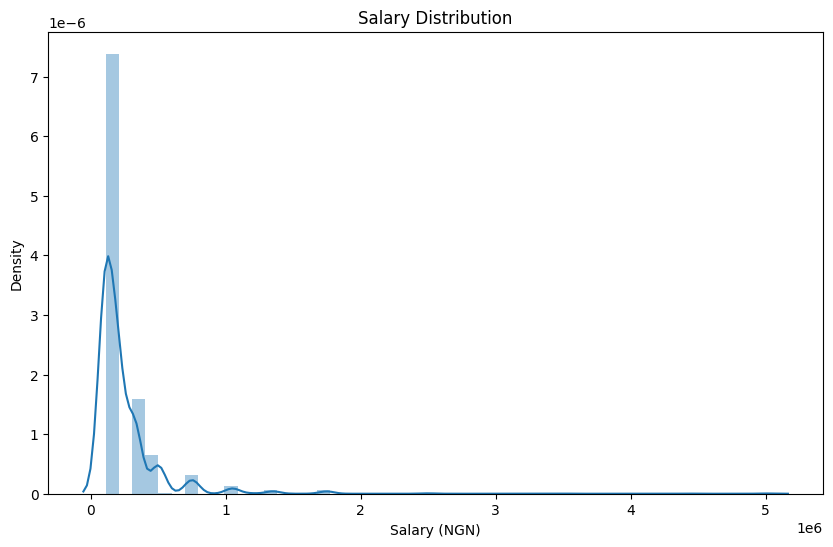

In [67]:
# distribution salary mid point
plt.figure(figsize=(10, 6))
sns.distplot(data['salary_mid'], kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary (NGN)")
plt.ylabel("Density")
plt.show()

**Observation**

The distribution above is right skewed as the tail is clearly strecthing towards the right signifiying few high salaries.

And this makes sense, because in the real world, especially most Nigerian jobs on Jobberman are entry to mid level with very few paying 3M - 5M

In [68]:
# mapping out each mid point to their respective category
def salary_category(salary_mid):
  # for missing values like the nans
  if pd.isna(salary_mid):
    return None
  if salary_mid <= 150000:
    return 'Entry Level'
  elif salary_mid <= 400000:
    return 'Mid Level'
  elif salary_mid <= 900000:
    return 'Senior Level'
  else:
    return'Executive'

# alternatively using the pd.cut
# data['salary_cat'] = pd.cut(
#     data['salary_mid'],
#     bins=[0, 150000, 400000, 900000, float('inf')],
#     labels=['Entry level',]
# )


# creating the category feature
data['salary_cat'] = data['salary_mid'].apply(salary_category)

# data['salary_cat'].value_counts()

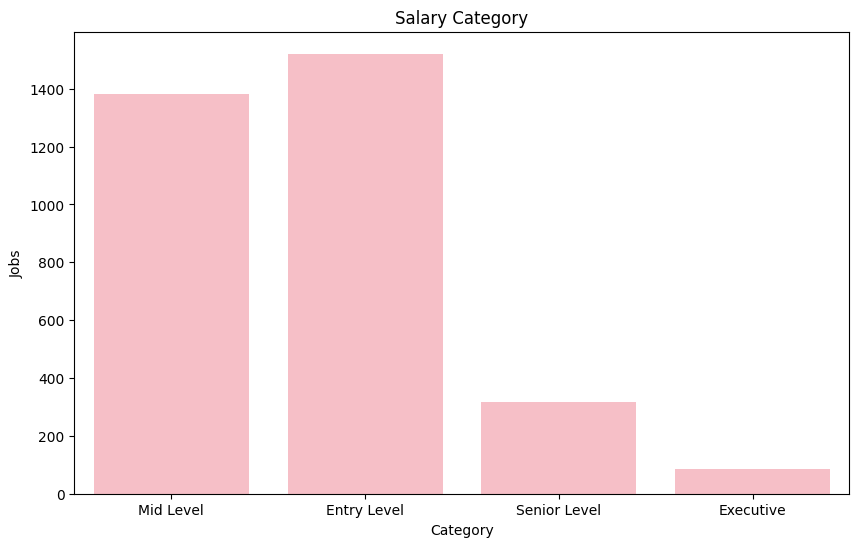

In [69]:
# countplot for salary count distribution

plt.figure(figsize=(10, 6))
sns.countplot(data, x='salary_cat', color='lightpink')
plt.title("Salary Category")
plt.xlabel("Category")
plt.ylabel("Jobs")
plt.show()


The barplot above clearly shows the imbalance class data.
The *Senior* and *Executive* class is to small to stand alone compared to the *Entry* and the *mid* level.

Realistically, theres a thin line between the *Senior* and *Executive* in Nigeria Job market. So merging them both will be better then oversampling the class during modelling.

In [70]:
# merging the senior and executive level
data['salary_cat'] = data['salary_cat'].replace({
    'Executive': 'Senior/Executive',
    'Senior Level': 'Senior/Executive'
    })
data['salary_cat'].value_counts()

,count
salary_cat,
Entry Level,1521
Mid Level,1383
Senior/Executive,404


### **Analayizing other Features**

**Experience Length**

In [71]:
data['experience_length'].value_counts()

,count
experience_length,
2 years,1178
3 years,807
1 year,755
No Experience/Less than 1 year,224
4 years,191
5 years,184
10 years,27
7 years,27
8 years,22


In [72]:
# experience length
def clean_experience(exp_str):
  if pd.isna(exp_str):
    return None

  if 'Full Time - Full Time' in exp_str:
    return None
  elif 'English' in exp_str:
    return None
  elif 'No Experience/Less than 1 year' in exp_str:
    return 0

  return int(exp_str.split()[0])

data['experience_length'] = data['experience_length'].apply(clean_experience)
data['experience_length'].value_counts()

,count
experience_length,
2.0,1178
3.0,807
1.0,755
0.0,224
4.0,191
5.0,184
10.0,27
7.0,27
8.0,22


**Location**

In [73]:
data['location'].value_counts()

,count
location,
Lagos,2098
Abuja,405
Port Harcourt & Rivers State,240
Remote (Work From Home),133
Ibadan & Oyo State,122
Abeokuta & Ogun State,118
Nigeria,42
Rest of Nigeria (Delta),31
Rest of Nigeria (Edo),29


In [74]:
def clean_location(location_str):
  #
  if 'Rest of Nigeria' in location_str:
    if '(' in location_str:
      return location_str.split('(')[1].split(')')[0]
    else:
      return "Other"

  elif '&' in location_str:
    location_str = location_str.split('&')[1].strip()
    return location_str

  elif 'Remote' in location_str:
    return 'Remote'

  elif 'Nationwide' in location_str:
    return 'Remote'
  elif 'Nigeria' in location_str:
    return 'Remote'

  else:
    return location_str


data['location'] = data['location'].apply(clean_location)
data['location'].value_counts()



,count
location,
Lagos,2098
Abuja,405
Rivers State,240
Remote,176
Oyo State,122
Ogun State,118
Delta,31
Edo,29
Nationwide,28


The imbalance class is noticeable in the Location dataset also. It would be wise to store anything below a threshold into "Other" section. Just to reduce the noise during training

**Date Posted**

In [75]:
data['date_posted'].value_counts()

,count
date_posted,
1 month ago,1375
3 weeks ago,537
1 week ago,459
2 weeks ago,395
4 weeks ago,255
Today,127
Yesterday,90
2 months ago,88
2 days ago,65


In [76]:
data['days_ago'] = data['date_posted'].map({
      'Today': 0,
      'Yesterday': 1,
      '2 days ago': 2,
      '6 days ago': 6,
      '1 week ago': 7,
      '2 weeks ago': 14,
      '3 weeks ago': 21,
      '4 weeks ago': 28,
      '1 month ago': 30,
      '2 month ago': 60,
      '3 month ago': 90
  })

print(data['days_ago'].value_counts())
print(data['days_ago'].isna().sum())

days_ago
30.0    1375
21.0     537
7.0      459
14.0     395
28.0     255
0.0      127
1.0       90
2.0       65
6.0       62
Name: count, dtype: int64
98


In [77]:
data['date_posted'].unique()

array(['Today', 'Yesterday', '2 days ago', '6 days ago', '1 week ago',
       '2 weeks ago', '2 months ago', '3 weeks ago', '4 weeks ago',
       '1 month ago', '3 months ago'], dtype=object)

**Minimum Qualification**

In [78]:
data['minimum_qualification'].value_counts()

,count
minimum_qualification,
Degree,1801
HND,548
High School (S.S.C.E),421
OND,372
Diploma,209
N.C.E,43
Vocational,23
MBA / MSc,21
Entry level,13


In the Minimum Qualification column, theres seems to be some entry that looks out of place like the 'Entry level', 'Mid level', 'Internship & Graduate', these should be in the experience level and not the qualifications.

There are only 16 rows in totals so i can easily set them as None Values.

In [79]:
def clean_min_qual(qual_str):
  if pd.isna(qual_str):
    return None

  if 'Entry level' in qual_str:
    return None
  elif 'Mid level' in qual_str:
    return None
  elif 'Internship & Graduate' in qual_str:
    return None
  else:
    return qual_str

data['minimum_qualification'] = data['minimum_qualification'].apply(clean_min_qual)
data['minimum_qualification'].value_counts()

,count
minimum_qualification,
Degree,1801
HND,548
High School (S.S.C.E),421
OND,372
Diploma,209
N.C.E,43
Vocational,23
MBA / MSc,21
MBBS,8


**Working Hour**

In [80]:
data['working_hour'].value_counts()

,count
working_hour,
Full Time,3263
Contract,119
Part Time,56
Internship & Graduate,25


This feature seems clean enough. Although the Full time has over 3000 instances of the total of about 3400, which is over 90%.

**Experience Level**

In [81]:
data['experience_level'].value_counts()

,count
experience_level,
Entry level,1984
Mid level,1007
Senior level,268
No Experience,102
Internship & Graduate,61
Executive level,25
2 years,9
1 year,4
No Experience/Less than 1 year,1


Seems like it has similar problem as the Minimum qualification.
**bold text**
Entries like the ***'1 year', '2years***' and all that shouldnt be here but in the **experience length**.

But since there are only 15 of this misplace entry I will clean the column by setting them as None

Additionally, the 'No experience' and 'Internship & Graduate' qualification sounds like the same to, so merging both of them wont be a bad idea. same thing with the 'Senior Level and Executive level'


In [82]:
def clean_level(level_str):
  if pd.isna(level_str):
    return None
  elif '1 year' in level_str:
    return None
  elif '2 years' in level_str:
    return None
  elif '3 years' in level_str:
    return None
  elif '4 years' in level_str:
    return None

  # merging the No experience with internship and graduate level
  elif 'No Experience' in level_str:
    return 'Internship & Graduate'
  # merging the Executive level with the senior level
  elif 'Executive level' in level_str:
    return 'Senior level'
  else:
    return level_str

data['experience_level'] = data['experience_level'].apply(clean_level)
data['experience_level'].value_counts()

,count
experience_level,
Entry level,1984
Mid level,1007
Senior level,293
Internship & Graduate,163


**Requirement & Responsibilities**

In [83]:
# analyzing
print(data['requirement'].iloc[0])
print('--------------------------')
print(data['responsibilities'].iloc[0])

['Minimum of an OND in marketing, business administration, or a related field', 'Proven experience in sales/marketing, preferably in FMCG (food & beverage)', 'Strong communication, negotiation, and interpersonal skills', 'Ability to work independently and meet targets', 'Good knowledge of the assigned state/market', 'Must be result-oriented and self-motivated']
--------------------------
['Develop and implement effective sales and marketing strategies to achieve company targets', 'Identify and onboard new distributors, wholesalers, and retailers', 'Promote and sell company products within assigned regions', 'Build and maintain strong relationships with customers and key stakeholders', 'Conduct market research to identify trends, customer needs, and competitor activities', 'Ensure proper product visibility and availability in the market', 'Meet and exceed monthly sales targets', 'Prepare and submit regular sales reports and market feedback', 'Represent the company professionally in all 

In [84]:
# checking the datatype of the column
print(type(data['requirement'].iloc[0]))
print(type(data['responsibilities'].iloc[0]))

<class 'str'>
<class 'str'>


This shows the dataset stored these columns as a string as soon as it was saved as a csv making it appear as a list


now, converting it back to a list...

In [85]:
def convert_to_list(text):
    try:
        if pd.isna(text):
            return []
    except:
        pass
    try:
        return ast.literal_eval(str(text))
    except:
        return []

data['requirement'] = data['requirement'].apply(convert_to_list)
data['responsibilities'] = data['responsibilities'].apply(convert_to_list)

# Verify
print(type(data['requirement'].iloc[0]))
print(data['requirement'].iloc[0])

<class 'list'>
['Minimum of an OND in marketing, business administration, or a related field', 'Proven experience in sales/marketing, preferably in FMCG (food & beverage)', 'Strong communication, negotiation, and interpersonal skills', 'Ability to work independently and meet targets', 'Good knowledge of the assigned state/market', 'Must be result-oriented and self-motivated']


**Done Cleaning...**

Saving cleaned dataset as another csv, just incase


In [86]:
data.to_csv("jobbermanm_cleaned.csv", index=False)
print("Cleaned data saved successfully")
print(data.shape)

Cleaned data saved successfully
(3463, 16)


## **Exploratory Data Analysis**

**Top Hiring Industries**

There are 26 distinct industries in the Jobbermann dataset




/tmp/ipykernel_6739/1538326378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data, y='job_category', order=data['job_category'].value_counts().index, palette='icefire')


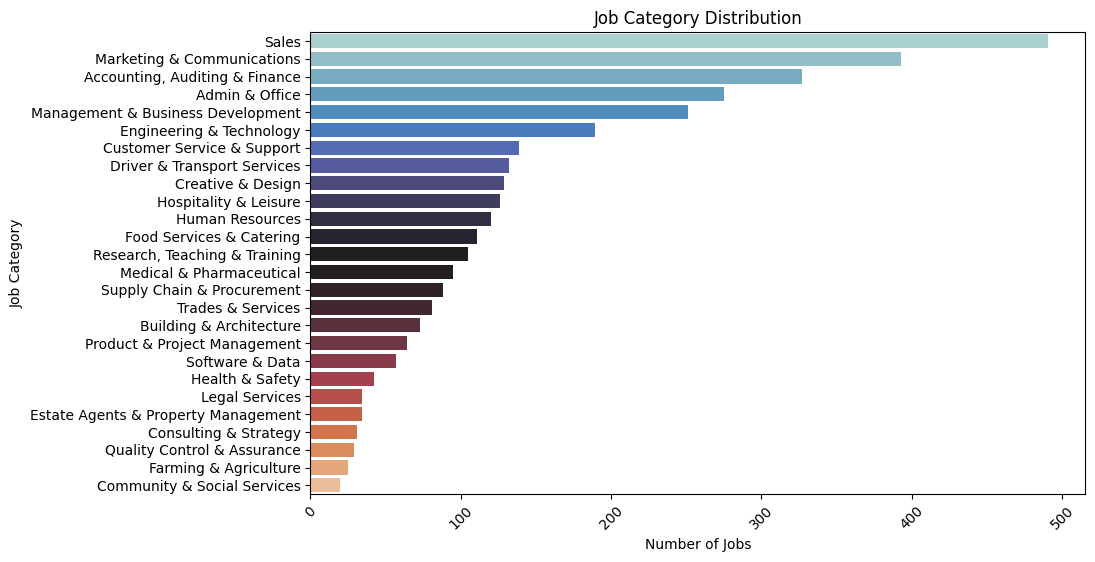

In [87]:
# Industries hiring the mosts
print(f"There are {data['job_category'].nunique()} distinct industries in the Jobbermann dataset\n\n")

# visualizing
plt.figure(figsize=(10, 6))
sns.countplot(data, y='job_category', order=data['job_category'].value_counts().index, palette='icefire')
plt.title("Top Hiring Industries in Jobbermann")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Category")
plt.title("Job Category Distribution")
plt.xticks(rotation=45)
plt.show()

**Observation**

* ***Sales***
* ***Marketing and Communication,***
* ***Accounting, Auditing & Finance***

are the top 3 industries hiring on Jobberman, each with over 300 listings. This makes sense as most Nigerian companies are always looking for
people to push their sales and manage finances.

 * *Farming & Agriculture*
 * *Community & social services*
  have the least listing, its more realistic that hiring in this sector is not usually done using online job portal like Jobbermann

**Location with the Most Listing**

The imbalance class is noticeable in the Location dataset also. It would be wise to store anything below a threshold into "Other" section. Just to reduce the noise during training

We could easily group all states/location that are less than 100 as others.


In [88]:
# grouping any location with 100 or less listing as other

location_counts = data['location'].value_counts()

low_counts = location_counts[location_counts < 100].index

data['location'] = data['location'].apply(
    lambda x: 'Other' if x in low_counts else x
    )

# verifying
data['location'].value_counts()

,count
location,
Lagos,2098
Abuja,405
Other,304
Rivers State,240
Remote,176
Oyo State,122
Ogun State,118


So states like: *Nigeria, Delta, Edo, Abia, Enugu, Osun, Akwa Ibom, Imo, Anambra, Ondo, Cross River, Kano, Kwara, Plateau, Benue, Adamawa, Kaduna, Nassarawa, Ekiti, Ebonyi, Katsina, Kogi, Bauchi, Bayelsa, Niger, Gombe, Zamfara, Sokoto, Outside Nigeria* listed in the dataset will be categorized as **Others**

/tmp/ipykernel_6739/2346896130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data, x='location', palette='crest')


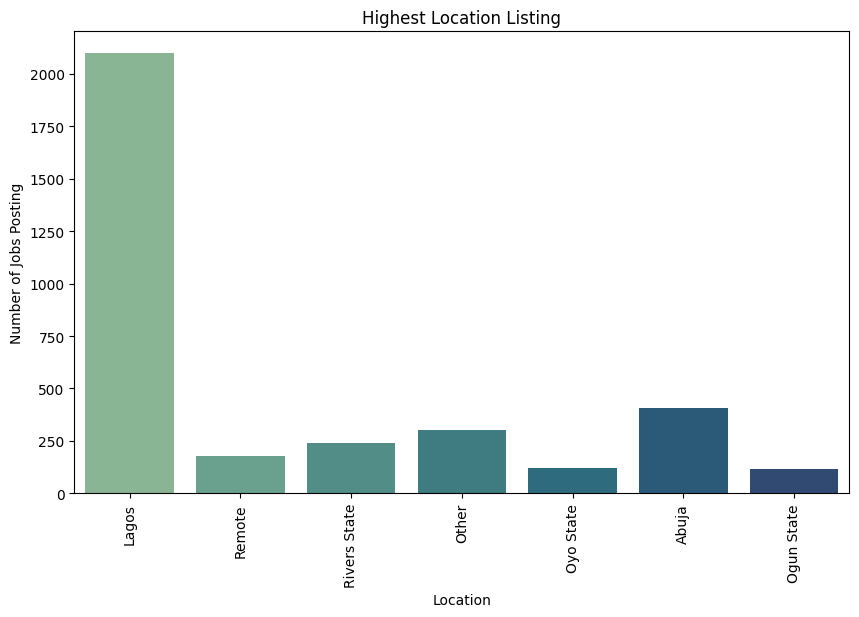

In [89]:
plt.figure(figsize=(10,6))
sns.countplot(data, x='location', palette='crest')
plt.title("Highest Location Listing")
plt.ylabel("Number of Jobs Posting")
plt.xlabel("Location")
plt.xticks(rotation=90)
plt.show()


***Lagos*** is the highest listed location for job in this dataset with over 2000 postings, followed by ***Abuja*** with around 400. this is expected as both cities are the main commercial hubs in Nigeria where most companies are headquartered

States like ***Kastina***, ***Delta*** and other smaller states are grouped under "**Other**" as they
individually account for less than 100 listings each.

**Salary Distribution Across Experience Level**

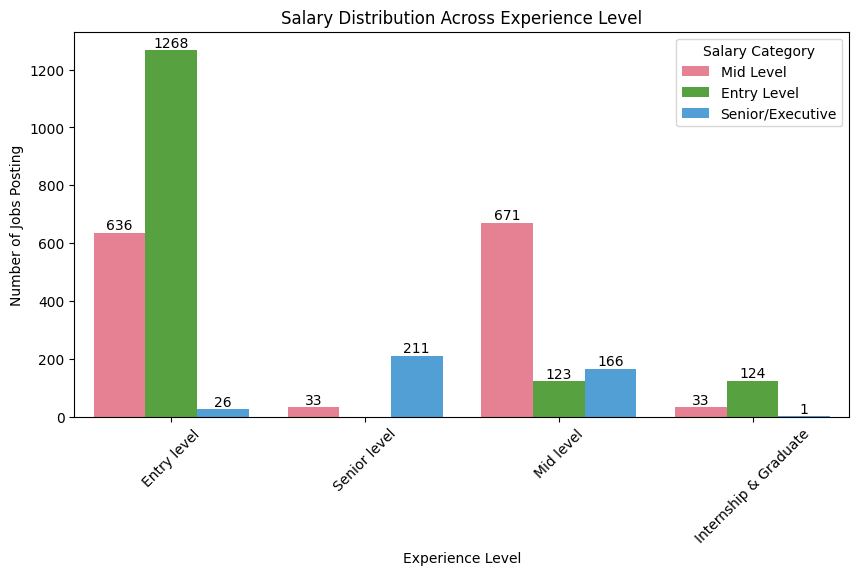

In [90]:
# salary and experience level
plt.figure(figsize=(10, 5))
ax = sns.countplot(data, x='experience_level', hue='salary_cat', palette='husl')
plt.title("Salary Distribution Across Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs Posting")
plt.legend(title="Salary Category")
plt.xticks(rotation=45)

for container in ax.containers:
  ax.bar_label(container, fmt='%d')

plt.show()

The chart confirms what you would expect in the real world.

***Entry level*** roles have the most job postings and are mostly paying *entry level salaries*, with very few offering senior/executive pay, *which* makes sense as companies rarely pay top salaries for junior roles.

***Senior level*** roles are mostly paying senior/executive salaries with
almost no entry level pay, confirming that experience is rewarded.

***Mid level*** roles sit in the middle as expected, with most postings
offering mid level salaries.

***Internship & Graduate*** roles are mostly entry level pay which is
expected for people just starting out.

*Overall, salary and experience level are well aligned in this dataset
which is a good sign for the quality of our data*

**Top In-Demand Skills**

In [91]:
# skill_list = [
#     'communication', 'teamwork', 'leadership', 'accountability', 'social media',
#     'content creation', 'budgeting', 'accounting', 'presentaion', 'project management',
#     'auditing', 'mentoring', 'retention', 'artificial intelligence', 'data analysis'
#     'data security', 'data privacy', 'versatility', 'ux', 'user development',
#     'brand management', 'seo', 'pr', 'public relation', 'e-commerce', 'organisation skill',
#     'driving', 'punctual', 'responsible', 'coaching', 'adaptability', 'problem solving',
#     'emotional intelligence', 'proactivity', 'innovation', 'resilience', 'curiousity',
#     'empathy', 'storytelling', 'writing', 'editing', 'negotiating', 'inquiring',
#     'body language', 'documenting', 'summarizing', 'customer service', 'conflict management',
#     'networking', 'collaboration', 'creative thinking', 'brainstorming', 'goal-setting',
#     'supervising', 'delegating', 'managing', 'training', 'influencing', 'earning trust',
#     'word processing', 'spreedsheet', 'coding', 'engineering', 'experimenting',
#     'testing', 'constructing', 'quality control', 'repairing', 'blueprint draft',
#     'translating', 'speaking', 'public speaking', 'proofreading', 'graphic design',
#     'user experience', 'user interface development', 'web design', 'data visualization',
#     'wireframing', 'research', 'information processing', 'modeling', 'predicting',
#     'forecasting', 'surveying', 'calculating', 'excel', 'power bi', 'tableau',
#     'sap', 'python', 'java', 'react', 'node js', 'javascript', 'r', 'c++', 'c',
#     'php', 'logistics', 'matlab', 'figma', 'adobe', 'matlab', 'supply', 'photoshop'
#     ]

In [92]:
# ai-generated skill
skills_list = [
    # --- Soft Skills ---
    'communication', 'teamwork', 'leadership', 'accountability',
    'problem solving', 'critical thinking', 'emotional intelligence',
    'adaptability', 'creativity', 'innovation', 'attention to detail',
    'time management', 'organization', 'negotiation', 'persuasion',
    'conflict resolution', 'decision making', 'public speaking',
    'presentation', 'storytelling', 'coaching', 'mentoring',
    'networking', 'collaboration', 'customer service', 'empathy',
    'resilience', 'self motivation', 'work ethic', 'integrity',

    # --- Management & Business ---
    'project management', 'product management', 'brand management',
    'business development', 'strategic planning', 'budgeting',
    'forecasting', 'risk management', 'change management',
    'operations management', 'supply chain', 'logistics',
    'procurement', 'inventory management', 'quality control',
    'process improvement', 'stakeholder management', 'reporting',
    'documentation', 'research', 'training', 'supervision',
    'team management', 'performance management',

    # --- Sales & Marketing ---
    'sales', 'marketing', 'digital marketing', 'social media',
    'content creation', 'content marketing', 'seo', 'sem',
    'email marketing', 'google analytics', 'media buying',
    'market research', 'customer acquisition', 'lead generation',
    'crm', 'hubspot', 'salesforce', 'copywriting', 'advertising',
    'public relations', 'e-commerce', 'affiliate marketing',
    'influencer marketing', 'campaign management',

    # --- Finance & Accounting ---
    'accounting', 'auditing', 'financial reporting', 'financial analysis',
    'tax', 'payroll', 'bookkeeping', 'quickbooks', 'sage',
    'financial modeling', 'investment', 'treasury', 'credit analysis',
    'loan processing', 'compliance', 'ifrs', 'budget management',
    'cost accounting', 'internal control', 'reconciliation',

    # --- Technology & Programming ---
    'python', 'sql', 'java', 'javascript', 'php', 'r',
    'c++', 'c#', 'react', 'node js', 'html', 'css',
    'django', 'flask', 'typescript', 'kotlin', 'swift',
    'machine learning', 'deep learning', 'artificial intelligence',
    'data analysis', 'data science', 'data visualization',
    'natural language processing', 'computer vision',
    'cloud computing', 'aws', 'azure', 'google cloud',
    'devops', 'docker', 'kubernetes', 'git', 'linux',
    'cybersecurity', 'network security', 'ethical hacking',
    'blockchain', 'api development', 'microservices',
    'mobile development', 'android', 'ios',

    # --- Data & Analytics Tools ---
    'excel', 'power bi', 'tableau', 'google sheets',
    'spss', 'stata', 'sas', 'looker', 'mysql',
    'postgresql', 'mongodb', 'hadoop', 'spark',

    # --- Design & Creative ---
    'graphic design', 'ui design', 'ux design', 'figma',
    'adobe photoshop', 'adobe illustrator', 'adobe premiere',
    'canva', 'web design', 'wireframing', 'prototyping',
    'video editing', 'photography', 'animation', 'autocad',

    # --- Engineering & Technical ---
    'mechanical engineering', 'electrical engineering',
    'civil engineering', 'structural engineering',
    'project engineering', 'welding', 'maintenance',
    'troubleshooting', 'blueprint reading', 'matlab',
    'solidworks', 'cad', 'hvac', 'oil and gas',

    # --- Healthcare ---
    'patient care', 'clinical research', 'pharmacology',
    'nursing', 'laboratory', 'diagnosis', 'health informatics',

    # --- Human Resources ---
    'recruitment', 'talent acquisition', 'onboarding',
    'employee relations', 'hr management', 'performance appraisal',
    'compensation', 'learning and development', 'succession planning',

    # --- Communication & Writing ---
    'writing', 'editing', 'proofreading', 'report writing',
    'proposal writing', 'technical writing', 'translation',
]

In [93]:
# extracting skills from the requirement columnn

# req_skill = []
def extract_skill(requirement_list):
  # for null values
  try:
    if pd.isna(requirement_list):
      return []
  except:
    pass

  # to join all list as one text
  req_skill = []
  text = ' '.join(requirement_list).lower()

    # loop through all skill list and check each one to return found skill
  for skill in skills_list:
    # to fix substring matching where the code finds only R programming language as skill and not any word with eht letter R
    # using regex
    pattern = r'\b' + re.escape(skill.lower()) + r'\b'
    if re.search(pattern, text):
    # if skill in requirement_list:
      req_skill.append(skill)

  return req_skill

data['extracted_skills'] = data['requirement'].apply(extract_skill)
print(data['extracted_skills'].head(10))


/tmp/ipykernel_6739/1114036489.py:7: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if pd.isna(requirement_list):


0       [communication, negotiation, sales, marketing]
1    [autocad, mechanical engineering, solidworks, ...
2    [autocad, mechanical engineering, solidworks, ...
3    [communication, teamwork, attention to detail,...
4                           [reporting, documentation]
5    [communication, negotiation, business developm...
6                                         [innovation]
7    [communication, negotiation, presentation, net...
8        [communication, persuasion, sales, marketing]
9                                         [accounting]
Name: extracted_skills, dtype: object


/tmp/ipykernel_6739/1799480876.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_df, x='count', y='skill', palette='viridis')


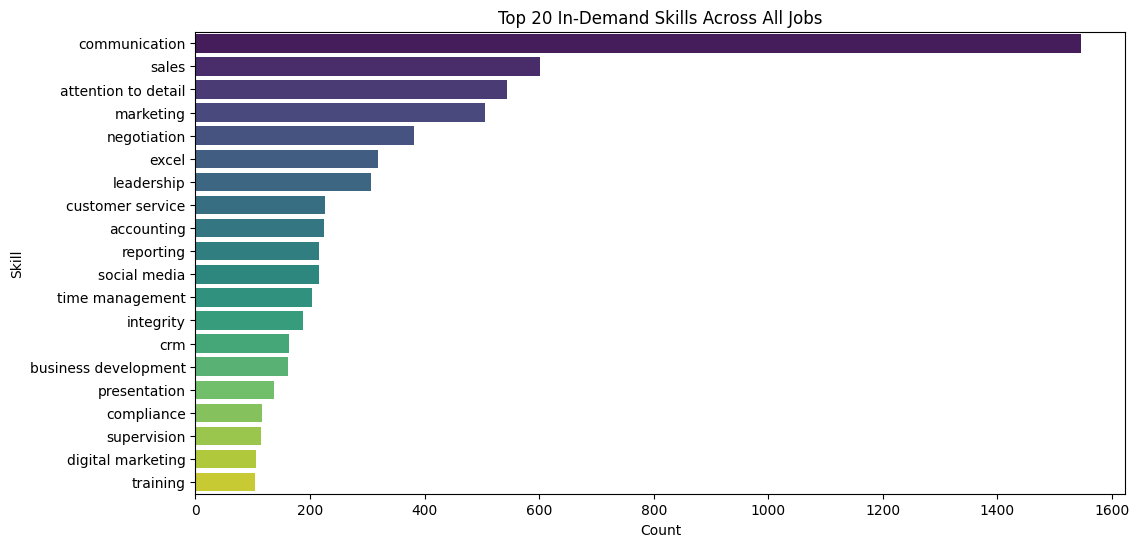

In [94]:
# visualize in demand skills across all jobs

# converting all the list of skills to one list
all_skills = [skill for s_list in data['extracted_skills'] for skill in s_list]
# counting each
skill_counts = Counter(all_skills)
# skill_counts

# getting top 20...
# first convert back to a dataframe
skill_df = pd.DataFrame(skill_counts.most_common(20), columns=['skill', 'count'])
# skill_df

# visualizing
plt.figure(figsize=(12, 6))
sns.barplot(data=skill_df, x='count', y='skill', palette='viridis')

plt.title('Top 20 In-Demand Skills Across All Jobs')
plt.xlabel('Count')
plt.ylabel('Skill')
plt.show()


***Communication*** is by far the most requested skill with nearly 1,600 job listings asking for it, almost every employer on Jobberman considers it essential regardless of industry or role.

***Sales, attention to detail and marketing*** follow behind, which aligns with our earlier finding that Sales and Marketing are the top hiring industries in Nigeria. Interestingly, Excel appears in the top 10, showing that spreadsheet skills are still highly valued even in non-technical roles.

Technical skills like ***Python and SQL*** don't appear in the top 20 at all, suggesting that most Nigerian job listings on **Jobberman** are business and operations focused rather than tech focused.

**Top Hiring Companies**

There are 1223 companies with job posting on Jobbermann


/tmp/ipykernel_6739/3166069459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data, y='company', order=data['company'].value_counts().index[:20], palette='crest')


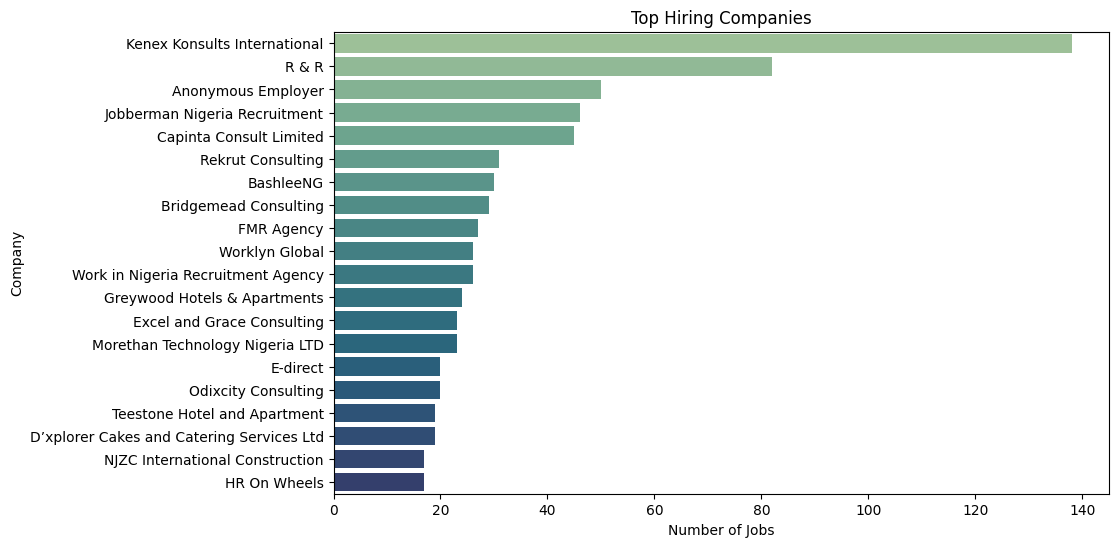

In [95]:
# visualizing top hiring companies

# data['company'].value_counts()

print(f"There are {data['company'].nunique()} companies with job posting on Jobbermann")

plt.figure(figsize=(10,6))
sns.countplot(data, y='company', order=data['company'].value_counts().index[:20], palette='crest')
plt.title("Top Hiring Companies")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")
plt.show()

Out of over 1,000 companies on Jobberman, **Kenex Konsults International** leads with nearly 140 job postings, significantly higher than everyone else. ***R&R*** follows with close to 100 postings.

However, a closer look at the top 20 reveals that most of them are recruitment and staffing agencies, companies like ***Rekrut Consulting,
Bridgemead Consulting, FMR Agency and Work in Nigeria Recruitment Agency.***

This means they are not the actual employers but are posting jobs on behalf of other companies. This also explains why **"Anonymous Employer"**
appears in the top 5, it seems like many companies prefer to hire without revealing their identity publicly.

**Qualification Distribution**

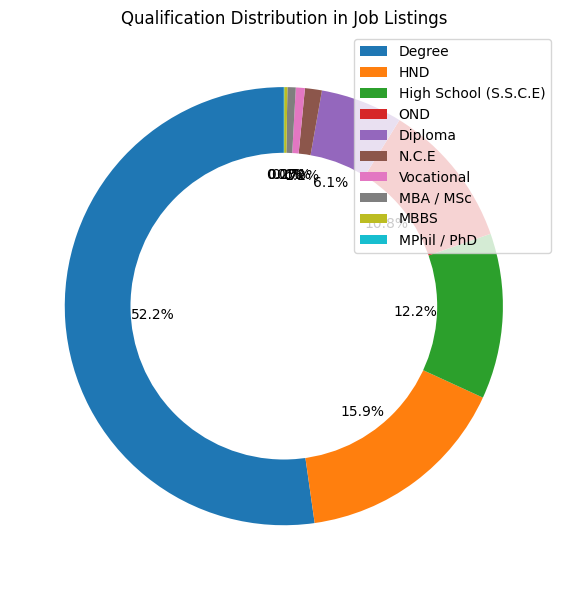

In [96]:
# plotting a donut chart to show qualification distribution

# getting the counts
qual_count = data['minimum_qualification'].value_counts()

# plotting
plt.figure(figsize=(10, 6))
plt.pie(qual_count.values,        # the numbers
        labels=None,               # remove labels from chart to avoid overlap
        autopct='%1.1f%%',         # show percentages
        startangle=90)             # start from top

# move labels to a legend instead
plt.legend(qual_count.index, loc='upper right')

# this draws a white circle in the middle to make it look like a donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Qualification Distribution in Job Listings')
plt.tight_layout()
plt.show()


Over half of all job listings on Jobberman (52.2%) require a ***university degree,*** making it the most common minimum qualification employers ask for.**HND** comes in second at 15.9%, followed by ***High School (S.S.C.E)*** at 12.2%
and ***OND*** at 10.8%.

This shows that while a degree is clearly preferred, there are still meaningful opportunities for candidates without one: ***HND, OND and High School*** qualifications together account for nearly 40% of listings, which is significant in the Nigerian context where not everyone has access to university education.

**Experience length & Salary category**

/tmp/ipykernel_6739/3779286741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='experience_length', y='salary_cat', palette='crest')


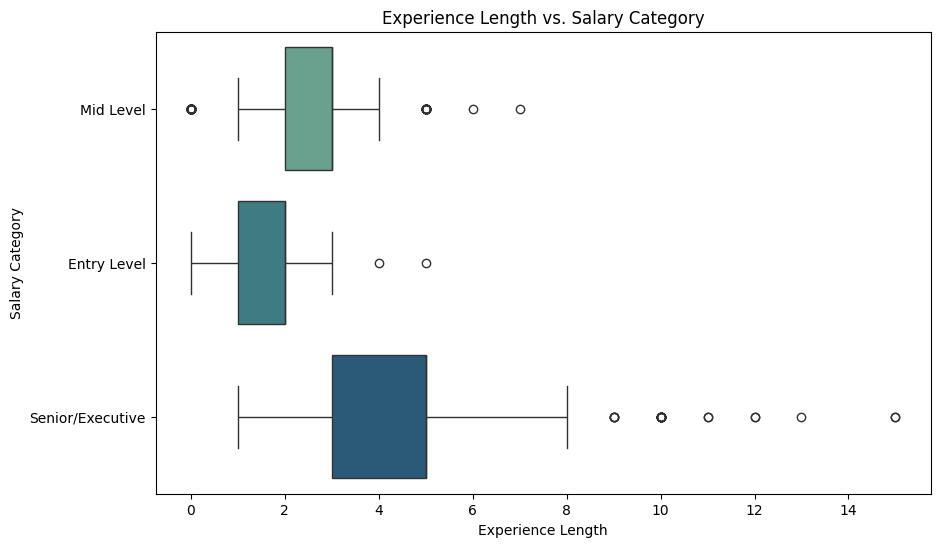

In [97]:
# using a boxplot to visualize the salary catagorry and the experience length
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='experience_length', y='salary_cat', palette='crest')
plt.title("Experience Length vs. Salary Category")
plt.xlabel("Experience Length")
plt.ylabel("Salary Category")
plt.show()

The boxplot confirms that experience and salary are positively related in the Nigerian job market, the more years of experience you have,
the higher your salary category tends to be.

**Entry level** roles typically require 1-2 years of experience, with some listings accepting candidates with zero experience. **Mid level** roles sit around 2-3 years, while **Senior/Executiv**e roles have the widest range, mostly 3-5 years but extending well beyond that, showing that
seniority varies more widely than the other categories.

The outlier dots on the right confirm that some employers post **senior** salaries for roles requiring 10-12 years of experience, which is
expected for executive positions.

## **Feature Engineering**

In [98]:
data.dtypes

,0
job_title,object
company,object
location,object
working_hour,object
salary_range,object
job_category,object
date_posted,object
minimum_qualification,object
experience_level,object
experience_length,float64


Before modelling, we need to ensure every column must be a number, but right nowm we still have text columns.


In [99]:
# visualizing a heatmap to see the variation of the salary category with other feature
data.head(2)

,job_title,company,location,working_hour,salary_range,job_category,date_posted,minimum_qualification,experience_level,experience_length,job_summary,responsibilities,requirement,salary_mid,salary_cat,days_ago,extracted_skills
0,Marketing/Sales Representative,Stevian Foods Ltd,Lagos,Full Time,"NGN 150,000 - 250,000",Sales,Today,OND,Entry level,2.0,We are seeking experienced and results-driven ...,[Develop and implement effective sales and mar...,"[Minimum of an OND in marketing, business admi...",200000.0,Mid Level,0.0,"[communication, negotiation, sales, marketing]"
1,Senior Mechanical Engineer.,Anonymous Employer,Lagos,Full Time,Confidential,Engineering & Technology,Today,Degree,Senior level,15.0,The successful candidate will be responsible f...,"[Design, develop, and maintain mechanical syst...",[Bachelor’s degree in Mechanical Engineering o...,NaN,None,0.0,"[autocad, mechanical engineering, solidworks, ..."


*There a couple of columns that wont be need in during training, so it will be safe to drop them now*

In [100]:
# letts create a column that counts how many skills each job requires
data['skill_count'] = data['extracted_skills'].apply(len)
# data.head()

In [101]:
# features we will be needing

feature = [
    'job_title', 'location', 'working_hour', 'job_category',
    'minimum_qualification', 'experience_level', 'experience_length', 'skill_count'
    ]

target = 'salary_cat'

In [102]:
# dataframe for the model
model_data = data[feature +[target]].copy()

# remove all row with null values in the salary category
model_data =  model_data.dropna(subset=[target])
print(f"The Model dataset now has {model_data.shape[0]} instances and {model_data.shape[1]} attribute")
print(f"\nNull Values\n------\n{model_data.isnull().sum()}")

The Model dataset now has 3308 instances and 9 attribute

Null Values
------
job_title                 0
location                  0
working_hour              0
job_category              1
minimum_qualification    16
experience_level         16
experience_length        16
skill_count               0
salary_cat                0
dtype: int64


*For the empty rows, we can easily drop the rows and thats only 16-17 rows of dat which is roughly about 0.5% of the data.*

In [103]:
# drop the empty rows
model_data = model_data.dropna()
print(f"The Model dataset now has {model_data.shape[0]} instances and {model_data.shape[1]} attribute")
print(f"\nNull Values\n------\n{model_data.isnull().sum()}")

The Model dataset now has 3291 instances and 9 attribute

Null Values
------
job_title                0
location                 0
working_hour             0
job_category             0
minimum_qualification    0
experience_level         0
experience_length        0
skill_count              0
salary_cat               0
dtype: int64


In [104]:
top_job = model_data['job_title'].value_counts().index[:50]

# any other job oustide the top 50 job should be categoriized as Other
model_data['job_title'] = model_data['job_title'].apply(lambda x: x if x in top_job else 'Other')

print(f"unique titles now: {model_data['job_title'].nunique()}")

unique titles now: 51


**Ordinal Encoding**

In [111]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

In [106]:
# converting to numerical order the minimum qualification and experience_level

qualification_order = ['High School (S.S.C.E)', 'OND', 'HND', 'Diploma', 'N.C.E',
                        'Degree', 'MBA / MSc', 'MPhil / PhD']

experience_order = ['Internship & Graduate', 'Entry level', 'Mid level', 'Senior level']



In [107]:
model_data['minimum_qualification'] = pd.Categorical(model_data['minimum_qualification'], categories=qualification_order, ordered=True).codes

model_data['experience_level'] = pd.Categorical(model_data['experience_level'], categories=experience_order, ordered=True).codes


# the -1 is vocational which is similar to the ond and all that so replacing with the median is fine
model_data['minimum_qualification'] = model_data['minimum_qualification'].replace(-1, 3)

In [108]:
print(model_data['minimum_qualification'].value_counts())
print(model_data['experience_level'].value_counts())

minimum_qualification
5    1698
2     524
0     411
1     357
3     236
4      43
6      21
7       1
Name: count, dtype: int64
experience_level
1    1930
2     960
3     244
0     157
Name: count, dtype: int64


**One Hot Encoding**

In [109]:
# features to convert to numbers using one hot encoding
oh_encode_feature = ['job_title' ,'location', 'working_hour', 'job_category']

model_data = pd.get_dummies(model_data, columns=oh_encode_feature, drop_first=False)
model_data.shape

(3291, 93)

In [116]:
# Also encoding Target variable

le = LabelEncoder()
model_data['salary_cat'] = le.fit_transform(model_data['salary_cat'])

#each numbers mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

print(model_data['salary_cat'].value_counts())
print(model_data['salary_cat'].dtype)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
salary_cat
0    1514
1    1373
2     404
Name: count, dtype: int64
int64


In [118]:
# from the encoding map
salary_mapping = {
    0: 'Entry Level',
    1: 'Mid Level',
    2: 'Senior/Executive'
}

print(salary_mapping)

{0: 'Entry Level', 1: 'Mid Level', 2: 'Senior/Executive'}
